#Reading csv file data

In [79]:
import pandas as pd
df = pd.read_csv('winequality (1).csv')
print(df)

      fixed acidity  volatile acidity  citric acid  ...  sulphates  alcohol  quality
0               7.4             0.700         0.00  ...       0.56      9.4        5
1               7.8             0.880         0.00  ...       0.68      9.8        5
2               7.8             0.760         0.04  ...       0.65      9.8        5
3              11.2             0.280         0.56  ...       0.58      9.8        6
4               7.4             0.700         0.00  ...       0.56      9.4        5
...             ...               ...          ...  ...        ...      ...      ...
1594            6.2             0.600         0.08  ...       0.58     10.5        5
1595            5.9             0.550         0.10  ...       0.76     11.2        6
1596            6.3             0.510         0.13  ...       0.75     11.0        6
1597            5.9             0.645         0.12  ...       0.71     10.2        5
1598            6.0             0.310         0.47  ...       0.6

In [80]:
import os

print(os.listdir())

['.config', 'drive', 'winequality (1).csv', 'sample_data']


#Checking the first five data

In [81]:
print(df.head())

   fixed acidity  volatile acidity  citric acid  ...  sulphates  alcohol  quality
0            7.4              0.70         0.00  ...       0.56      9.4        5
1            7.8              0.88         0.00  ...       0.68      9.8        5
2            7.8              0.76         0.04  ...       0.65      9.8        5
3           11.2              0.28         0.56  ...       0.58      9.8        6
4            7.4              0.70         0.00  ...       0.56      9.4        5

[5 rows x 12 columns]


#Data information

In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


#Data description

In [42]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_label
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023,0.135710
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569,0.342587
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000,0.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000,0.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000,0.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,1.000000


#Checking null values if any

In [43]:
print(df.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
quality_label           0
dtype: int64


Implementing correlation for better data understanding

In [44]:
corr_matrix=df.corr()

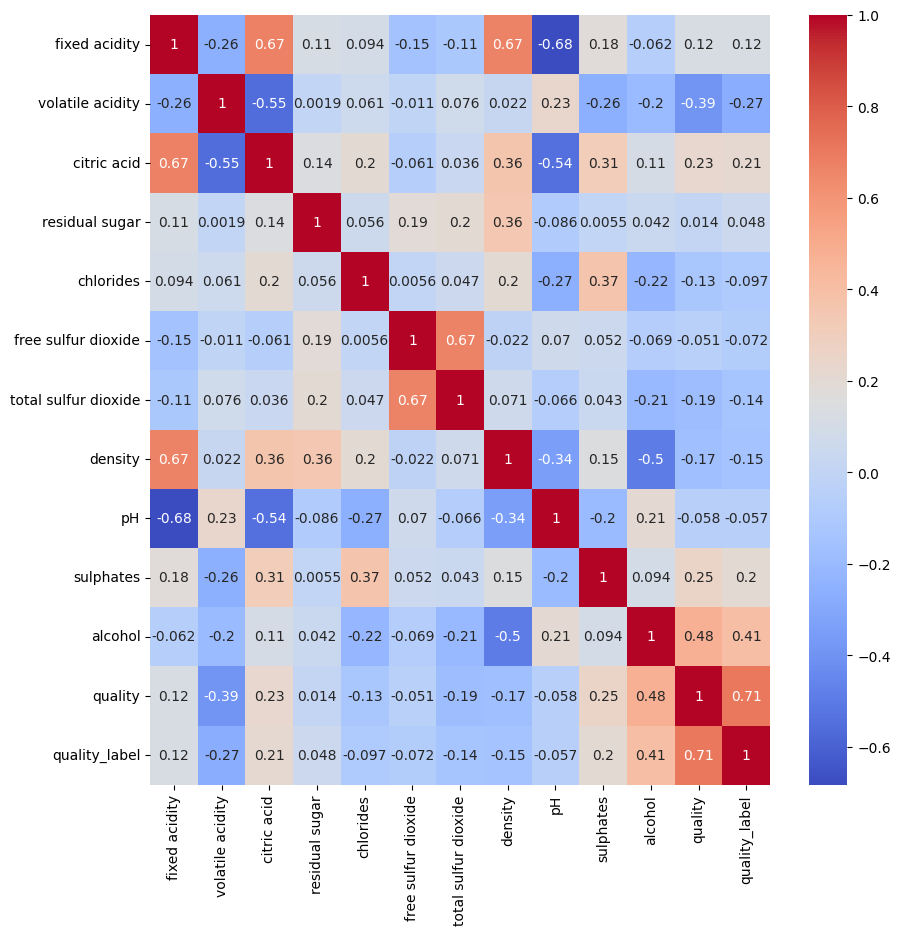

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,10))
sns.heatmap(corr_matrix,annot=True,cmap="coolwarm")
plt.show()

#Checking the quality correlation.

In [46]:
quality_corr = corr_matrix["quality"].sort_values(ascending=False)

print(quality_corr)

quality                 1.000000
quality_label           0.710196
alcohol                 0.476166
sulphates               0.251397
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.013732
free sulfur dioxide    -0.050656
pH                     -0.057731
chlorides              -0.128907
density                -0.174919
total sulfur dioxide   -0.185100
volatile acidity       -0.390558
Name: quality, dtype: float64


In [7]:
df["quality_label"]=(df["quality"]>=7).astype(int)
print(df["quality_label"].head())

0    0
1    0
2    0
3    0
4    0
Name: quality_label, dtype: int64


#Features and target value

In [8]:
X=df.drop(["quality","quality_label"],axis=1)
Y=df["quality_label"]
print(X.head())
print(Y.head())

   fixed acidity  volatile acidity  citric acid  ...    pH  sulphates  alcohol
0            7.4              0.70         0.00  ...  3.51       0.56      9.4
1            7.8              0.88         0.00  ...  3.20       0.68      9.8
2            7.8              0.76         0.04  ...  3.26       0.65      9.8
3           11.2              0.28         0.56  ...  3.16       0.58      9.8
4            7.4              0.70         0.00  ...  3.51       0.56      9.4

[5 rows x 11 columns]
0    0
1    0
2    0
3    0
4    0
Name: quality_label, dtype: int64


#Train-test-split data

In [9]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)

(1279, 11)
(320, 11)


#Training data through logistic regression(unscaled)

In [14]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(X_train,Y_train)
print("Model trained successfully through logistic regression")

Model trained successfully through logistic regression


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic regression prediction

In [15]:
l_prediction=model.predict(X_test)
print(l_prediction[:5])

[0 0 0 0 0]


Logistic regression metrics analysis

In [22]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
accuracy=accuracy_score(Y_test,l_prediction)
precision=precision_score(Y_test,l_prediction)
recall=recall_score(Y_test,l_prediction)
f1=f1_score(Y_test,l_prediction)
c_matrix=confusion_matrix(Y_test,l_prediction)

print("Accuracy:",accuracy)
print("Precision:",precision)
print("Recall:",recall)
print("F1 Score:",f1)
print("Confusion Matrix:")
print(c_matrix)


Accuracy: 0.865625
Precision: 0.625
Recall: 0.2127659574468085
F1 Score: 0.31746031746031744
Confusion Matrix:
[[267   6]
 [ 37  10]]


#Scaling data

In [23]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
print(X_train_scaled[:5])

[[ 0.21833164  0.88971201  0.19209222  0.30972563 -0.04964208  0.69100692
   1.04293362  1.84669643  1.09349989  0.45822284  1.12317723]
 [-1.29016623 -1.78878251  0.65275338 -0.80507963 -0.45521361  2.38847304
   3.59387025 -3.00449133 -0.40043872 -0.40119696  1.40827174]
 [ 1.49475291 -0.78434707  1.01104539 -0.52637831  0.59927236 -0.95796016
  -0.99174203  0.76865471 -0.07566946  0.51551749 -0.58738978]
 [ 0.27635078  0.86181102 -0.06383064 -0.66572897 -0.00908493  0.01202048
  -0.71842739  0.08948842  0.05423824 -1.08873281 -0.96751578]
 [ 0.04427419  2.81487994 -0.62686095  2.39998549 -0.31326357 -0.47296984
   0.2229897   1.1998714   0.37900751 -0.9741435  -0.49235828]]


#Traing data through logistic regression(scaled)

In [24]:
scaled_model=LogisticRegression()
scaled_model.fit(X_train_scaled,Y_train)
print("Model trained successfully through logistic regression with scaled value")

Model trained successfully through logistic regression with scaled value


Prediction of scaled data

In [25]:
scaled_prediction=scaled_model.predict(X_test_scaled)
print(scaled_prediction[:5])

[0 0 0 0 0]


Metrics analysis for scaled value

In [26]:
S_accuracy=accuracy_score(Y_test,scaled_prediction)
S_precision=precision_score(Y_test,scaled_prediction)
S_recall=recall_score(Y_test,scaled_prediction)
S_f1=f1_score(Y_test,scaled_prediction)
S_c_matrix=confusion_matrix(Y_test,scaled_prediction)

print("Accuracy:",S_accuracy)
print("Precision:",S_precision)
print("Recall:",S_recall)
print("F1 Score:",S_f1)
print("Confusion Matrix:")
print(S_c_matrix)


Accuracy: 0.865625
Precision: 0.5909090909090909
Recall: 0.2765957446808511
F1 Score: 0.37681159420289856
Confusion Matrix:
[[264   9]
 [ 34  13]]


Prediction for scaled trained value

In [60]:
scaled_predict=[[7.4, 0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51, 0.56,9.4]]
scaled_data=scaler.transform(scaled_predict)
print(scaled_model.predict(scaled_data))

[0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


Comparision between metrics values

In [28]:
comparison=pd.DataFrame({

    "Accuracy":[accuracy,S_accuracy],
    "Precision":[precision,S_precision],
    "Recall":[recall,S_recall],
    "F1 Score":[f1,S_f1]
})
print(comparison)

   Accuracy  Precision    Recall  F1 Score
0  0.865625   0.625000  0.212766  0.317460
1  0.865625   0.590909  0.276596  0.376812


#Training data using KNN

In [29]:
from sklearn.neighbors import KNeighborsClassifier
knn_model=KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled,Y_train)
print("Model trained successfully through KNN")

Model trained successfully through KNN


Prediction after trained from knn

In [30]:
knn_prediction=knn_model.predict(X_test_scaled)
print(knn_prediction)

[0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0
 0 0 1 0 0 1 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0
 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 0
 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0]


Metrics analysis for knn value

In [31]:
k_accuracy=accuracy_score(Y_test,knn_prediction)
k_precision=precision_score(Y_test,knn_prediction)
k_recall=recall_score(Y_test,knn_prediction)
k_f1=f1_score(Y_test,knn_prediction)
k_c_matrix=confusion_matrix(Y_test,knn_prediction)

print("Accuracy:",k_accuracy)
print("Precision:",k_precision)
print("Recall:",k_recall)
print("F1 Score:",k_f1)
print("Confusion Matrix:")
print(k_c_matrix)


Accuracy: 0.88125
Precision: 0.6451612903225806
Recall: 0.425531914893617
F1 Score: 0.5128205128205128
Confusion Matrix:
[[262  11]
 [ 27  20]]


KNN prediction

In [61]:
k_predict=[[7.4, 0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51, 0.56,9.4]]
k_scaled_predict=scaler.transform(k_predict)
print(knn_model.predict(k_scaled_predict))

[0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


#Training data using DecisionTreeClassifier

In [62]:
from sklearn.tree import DecisionTreeClassifier
dt_model=DecisionTreeClassifier()
dt_model.fit(X_train,Y_train)
print("Model trained successfully through Decision Tree")

Model trained successfully through Decision Tree


Decision tree trained data prediction

In [63]:
dt_prediction=dt_model.predict(X_test)
print(dt_prediction)

[0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 1 0 1 0 0 0 0 0
 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0
 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 1 0 1 0 0 1 0 0 0 0 0 0 0 0
 0 0 0 0 0 1 1 0 0 0 1 0 0 1 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 1 1 0 1 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0
 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0]


Metrics analysis for decision tree

In [35]:
d_accuracy=accuracy_score(Y_test,dt_prediction)
d_precision=precision_score(Y_test,dt_prediction)
d_recall=recall_score(Y_test,dt_prediction)
d_f1=f1_score(Y_test,dt_prediction)
d_c_matrix=confusion_matrix(Y_test,dt_prediction)
print("Accuracy:",d_accuracy)
print("Precision:",d_precision)
print("Recall:",d_recall)
print("F1 Score:",d_f1)
print("Confusion Matrix:")
print(d_c_matrix)


Accuracy: 0.86875
Precision: 0.5581395348837209
Recall: 0.5106382978723404
F1 Score: 0.5333333333333333
Confusion Matrix:
[[254  19]
 [ 23  24]]


Decision tree trained model prediction

In [36]:
dt_predict=[[7.4, 0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51, 0.56,9.4]]
print(dt_model.predict(dt_predict))

[0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


#Models metrics comparision

In [37]:
all_models_data = {
    "Model": ["Logistic Regression (Scaled)", "Knn", "Decision Tree"],
    "Accuracy": [S_accuracy,k_accuracy,d_accuracy],
    "Precision": [S_precision, k_precision, d_precision],
    "Recall": [S_recall, k_recall, d_recall],
    "F1 Score": [S_f1, k_f1, d_f1]
}
comparison_df = pd.DataFrame(all_models_data)
print(comparison_df)

                          Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression (Scaled)  0.865625   0.590909  0.276596  0.376812
1                           Knn  0.881250   0.645161  0.425532  0.512821
2                 Decision Tree  0.868750   0.558140  0.510638  0.533333


#Comparision graph

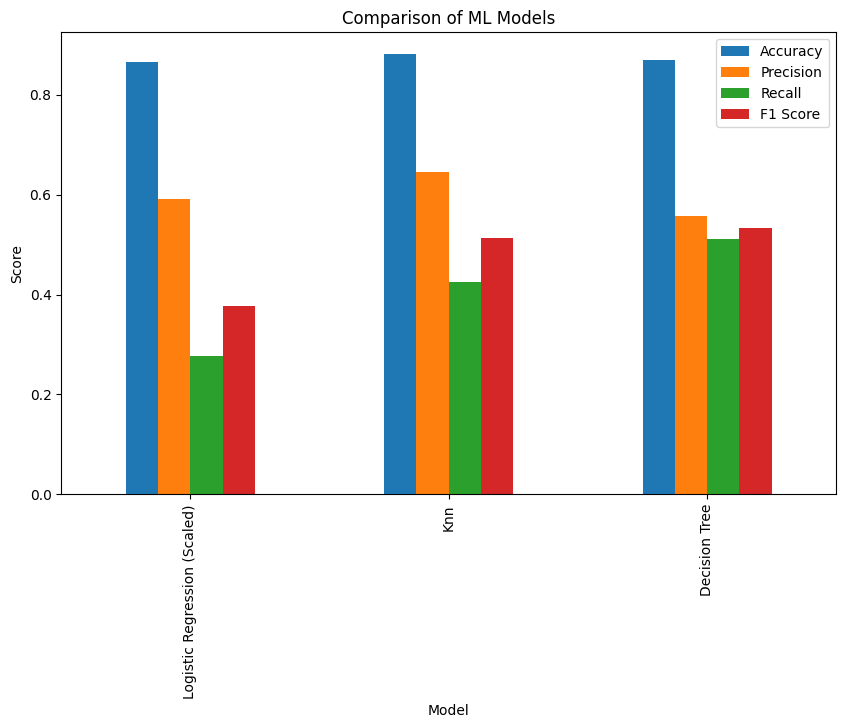

In [47]:
comparison_df.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Comparison of ML Models")
plt.ylabel("Score")
plt.show()

#Hyperparameters for best model among the models used

In [52]:
p_grid={
    "n_neighbors":[10,50,100],
    "weights":["uniform","distance"]
}


Grid Search CV

In [56]:
from sklearn.model_selection import GridSearchCV
grid_find=GridSearchCV(KNeighborsClassifier(),p_grid,cv=5)
grid_find.fit(X_train_scaled,Y_train)
print(grid_find.best_params_)

{'n_neighbors': 50, 'weights': 'distance'}


Training using best model

In [57]:
best_model=grid_find.best_estimator_
best_prediction=best_model.predict(X_test_scaled)
print(best_prediction[:5])

[0 0 0 0 0]


Best model accuracy analysis

In [58]:
print(accuracy_score(Y_test,best_prediction))

0.8875


#Feature importance

In [65]:
from sklearn.inspection import permutation_importance
result=permutation_importance(best_model,X_test_scaled,Y_test,n_repeats=10,random_state=42)
print(result)

{'importances_mean': array([0.0303125, 0.028125 , 0.0271875, 0.0284375, 0.026875 , 0.0253125,
       0.02375  , 0.03125  , 0.02625  , 0.0375   , 0.0290625]), 'importances_std': array([0.0055989 , 0.00592927, 0.00625781, 0.00616346, 0.00423896,
       0.00676763, 0.00673146, 0.00790569, 0.00423896, 0.00765466,
       0.0065625 ]), 'importances': array([[0.021875, 0.0375  , 0.03125 , 0.034375, 0.03125 , 0.028125,
        0.025   , 0.034375, 0.021875, 0.0375  ],
       [0.025   , 0.0375  , 0.03125 , 0.021875, 0.015625, 0.028125,
        0.028125, 0.028125, 0.034375, 0.03125 ],
       [0.01875 , 0.03125 , 0.040625, 0.028125, 0.01875 , 0.03125 ,
        0.028125, 0.028125, 0.021875, 0.025   ],
       [0.034375, 0.03125 , 0.028125, 0.021875, 0.028125, 0.021875,
        0.01875 , 0.03125 , 0.040625, 0.028125],
       [0.034375, 0.021875, 0.021875, 0.025   , 0.03125 , 0.028125,
        0.028125, 0.021875, 0.03125 , 0.025   ],
       [0.034375, 0.034375, 0.028125, 0.025   , 0.025   , 0.021875,


In [66]:
importances=pd.DataFrame({
    "Features":X.columns,
    "Importance":result.importances_mean})
importances=importances.sort_values("Importance",ascending=False)
print(importances)


                Features  Importance
9              sulphates    0.037500
7                density    0.031250
0          fixed acidity    0.030312
10               alcohol    0.029062
3         residual sugar    0.028437
1       volatile acidity    0.028125
2            citric acid    0.027187
4              chlorides    0.026875
8                     pH    0.026250
5    free sulfur dioxide    0.025312
6   total sulfur dioxide    0.023750


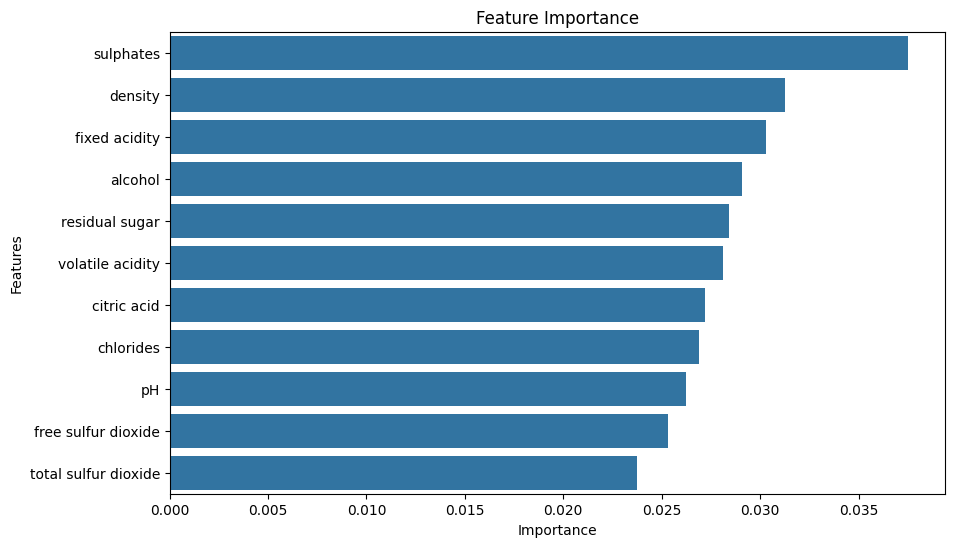

In [68]:
plt.figure(figsize=(10,6))
sns.barplot(x="Importance",y="Features",data=importances)
plt.title("Feature Importance")
plt.show()

#Prediction after best model training

In [70]:
fa=float(input("Enter fixed acidity: "))
va=float(input("Enter volatile acidity: "))
ca=float(input("Enter citric acid: "))
rs=float(input("Enter residual sugar: "))
cl=float(input("Enter chlorides: "))
fl=float(input("Enter free sulfur dioxide: "))
ts=float(input("Enter total sulfur dioxide: "))
d=float(input("Enter density: "))
ph=float(input("Enter pH: "))
s=float(input("Enter sulphates: "))
a=float(input("Enter alcohol: "))
print("Your product details are as follows:")
print("Fixed Acidity:",fa)
print("Volatile Acidity:",va)
print("Citric Acid:",ca)
print("Residual Sugar:",rs)
print("Chlorides:",cl)
print("Free Sulphur Dioxide:",fl)
print("Total Sulphur Dioxide:",ts)
print("Density:",d)
print("pH:",ph)
print("Sulphates:",s)
print("Alcohol:",a)
new_wine=[[fa,va,ca,rs,cl,fl,ts,d,ph,s,a]]
new_wine_scaled = scaler.transform(new_wine)
predict_new=best_model.predict(new_wine_scaled)

if predict_new[0]==1:
  print("The quality of the wine is: Good")
else:
  print("The quality of the wine is: Bad")


Enter fixed acidity: 8.8
Enter volatile acidity: 0.25
Enter citric acid: 0.45
Enter residual sugar: 2.1
Enter chlorides: 0.050
Enter free sulfur dioxide: 12
Enter total sulfur dioxide: 35
Enter density: 0.9940
Enter pH: 3.30
Enter sulphates: 0.90
Enter alcohol: 13.5
Your product details are as follows:
Fixed Acidity: 8.8
Volatile Acidity: 0.25
Citric Acid: 0.45
Residual Sugar: 2.1
Chlorides: 0.05
Free Sulphur Dioxide: 12.0
Total Sulphur Dioxide: 35.0
Density: 0.994
pH: 3.3
Sulphates: 0.9
Alcohol: 13.5
The quality of the wine is: Good


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
